<a href="https://colab.research.google.com/github/Vishal-JG/Fraud-Detection-Classifier/blob/main/ML_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection with Logistic Regression (from scratch)

**Task.** Given one credit card transaction, estimate the probability that it is fraudulent.

- **Input (deployment):** one transaction as a 29-dimensional real vector: V1–V28 (PCA components, anonymised by the data provider) and log(1 + Amount), standardised with the training-set mean and std.
- **Output:** a probability $p \in [0, 1]$ that the transaction is fraud. The transaction is flagged if $p \ge t$ (threshold $t$, tuned on validation data).
- **Training data:** 283,726 labelled transactions (after removing duplicates), of which 473 (0.167%) are fraud.

**Pipeline:** load data → remove duplicates → quick checks → preprocess and split → logistic regression from scratch → gradient check → baseline CV → class-weight sweep → threshold tuning → final test.

In [ ]:
# ===============================================================
# 1. ENVIRONMENT SETUP, IMPORTS AND DATA DOWNLOAD
# ===============================================================
!pip -q install kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, average_precision_score,
                             precision_recall_curve)

# sklearn is only used for splitting, scaling and computing metrics.
# The model itself (hypothesis, loss, gradient, gradient descent) is
# written from scratch in Section 5.

dataset_path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", dataset_path)
print("Files:", os.listdir(dataset_path))

df = pd.read_csv(os.path.join(dataset_path, "creditcard.csv"))
print("Shape:", df.shape)   # columns: Time, V1-V28, Amount, Class

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to: /kaggle/input/creditcardfraud
Files: ['creditcard.csv']
Shape: (284807, 31)


## 2. Removing duplicate rows
The raw data has exact duplicate rows. They are removed **before** splitting: if one copy ended up in training and its twin in the test set, the model would be tested on a transaction it had already seen (data leakage), which would make the results look better than they really are.

In [ ]:
# ===============================================================
# 2. REMOVE DUPLICATE ROWS
# ===============================================================
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows (extra copies): {n_dupes}")

# keep=False marks every copy, so we can see which classes are affected
dupe_mask = df.duplicated(keep=False)
print("Rows involved in duplication, by class:")
print(df.loc[dupe_mask, "Class"].value_counts())

fraud_dupes = df[df.duplicated() & (df["Class"] == 1)]
print(f"Extra copies that are fraud: {len(fraud_dupes)}")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(df)} rows. New shape: {df.shape}")

Exact duplicate rows (extra copies): 1081
Rows involved in duplication, by class:
Class
0    1822
1      32
Name: count, dtype: int64
Extra copies that are fraud: 19

Dropped 1081 rows. New shape: (283726, 31)


## 3. Quick checks: class balance, missing values, correlation
- **Class balance:** fraud is only ~0.17% of transactions. A model that always says "legit" would score ~99.8% accuracy while catching zero fraud, so **accuracy is not a useful metric here**. I use precision, recall and F1 for the fraud class instead.
- **Missing values:** none, so no imputation is needed.
- **Correlation with the label:** several PCA components (V17, V14, V12, V10) have a moderate linear correlation with fraud. This *suggests* a linear decision boundary is a reasonable first model. It doesn't prove the classes are linearly separable. This check is only used to justify the model choice, not for training.

In [ ]:
# ===============================================================
# 3. CLASS BALANCE, MISSING VALUES, CORRELATION
# ===============================================================

# --- Class balance ---
class_counts = df["Class"].value_counts().sort_index()
print("Class counts:\n", class_counts)
print(f"Fraud rate: {class_counts[1]} / {len(df)} = {100*class_counts[1]/len(df):.4f}%")

# --- Missing values ---
print(f"\nMissing values in whole dataset: {df.isnull().sum().sum()}")

# --- Correlation of each feature with the label (Time excluded, see Section 4) ---
corr_with_class = (
    df.drop(columns=["Time"])
      .corr()["Class"]
      .drop("Class")
      .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("\nTop 10 features by |correlation| with Class:")
print(corr_with_class.head(10).round(3))

Class counts:
 Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate: 473 / 283726 = 0.1667%

Missing values in whole dataset: 0

Top 10 features by |correlation| with Class:
V17   -0.313
V14   -0.293
V12   -0.251
V10   -0.207
V16   -0.187
V3    -0.182
V7    -0.172
V11    0.149
V4     0.129
V18   -0.105
Name: Class, dtype: float64


## 4. Preprocessing, train/test split and cross-validation folds
- **Drop `Time`:** it is seconds since the first transaction in the dataset, not a time of day, so it has no meaning for a new transaction at deployment.
- **log(1 + Amount):** Amount is heavily right-skewed. The log compresses large values; the +1 handles Amount = 0.
- **80/20 stratified split:** both sets keep the same fraud rate. The test set is not touched until the final evaluation (Section 11).
- **Stratified 5-fold CV** on the training set, used for choosing the class weight and the threshold.
- **Scaling inside each fold:** the StandardScaler is fit on each fold's training part only, then applied to its validation part, so validation statistics never leak into training.

In [ ]:
# ===============================================================
# 4. PREPROCESSING, TRAIN/TEST SPLIT AND CV FOLDS
# ===============================================================

# Work on a copy so df stays as the cleaned dataset and this cell can be re-run safely
df_model = df.drop(columns=["Time"]).copy()
df_model["Amount"] = np.log1p(df_model["Amount"])   # log(1 + Amount)

X = df_model.drop(columns=["Class"])   # 29 features: V1-V28 + Amount
y = df_model["Class"]                  # 0 = legit, 1 = fraud

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print(f"Train fraud: {y_train.sum()} ({100*y_train.mean():.4f}%)")
print(f"Test fraud:  {y_test.sum()} ({100*y_test.mean():.4f}%)")

# --- 5 stratified folds, scaler fit on each fold's training part only ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_folds = []   # list of (X_tr, y_tr, X_val, y_val), already scaled

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train.iloc[tr_idx])   # fit on fold-train only
    X_val = scaler.transform(X_train.iloc[val_idx])     # reuse the same mean/std
    y_tr = y_train.iloc[tr_idx].values
    y_val = y_train.iloc[val_idx].values
    cv_folds.append((X_tr, y_tr, X_val, y_val))
    print(f"Fold {fold_idx+1}: train={len(y_tr)} (fraud={y_tr.sum()}), "
          f"val={len(y_val)} (fraud={y_val.sum()})")

# --- Separate scaler for the final model: fit on all training data, applied to test ---
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train)
X_test_final_scaled = final_scaler.transform(X_test)

X_train: (226980, 29)  X_test: (56746, 29)
Train fraud: 378 (0.1665%)
Test fraud:  95 (0.1674%)
Fold 1: train=181584 (fraud=303), val=45396 (fraud=75)
Fold 2: train=181584 (fraud=303), val=45396 (fraud=75)
Fold 3: train=181584 (fraud=302), val=45396 (fraud=76)
Fold 4: train=181584 (fraud=302), val=45396 (fraud=76)
Fold 5: train=181584 (fraud=302), val=45396 (fraud=76)


## 5. Logistic regression from scratch

**1. Prediction (hypothesis).** Each transaction is a list of 29 numbers $\mathbf{x}$. The model multiplies each feature by a learned weight, adds them up, adds a bias $b$, and squashes the result into a score between 0 and 1 with the sigmoid function:
$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$
A score near 1 means "likely fraud", near 0 means "likely legit". The boundary between the two is a flat surface (a straight line in 2D), so this is a *linear* classifier.

**2. Loss (how wrong the model is).** Weighted binary cross-entropy:
$$L = \frac{1}{\sum_i s_i} \sum_{i} s_i \Big[ -y_i \log \hat{y}_i - (1 - y_i) \log (1 - \hat{y}_i) \Big]$$
For a fraud ($y=1$) the penalty is $-\log \hat{y}$: small if the model gave a high score, very large if it gave a low one. For a legit transaction ($y=0$) it is the reverse. Each penalty is multiplied by a weight $s_i$ (1 for legit, 10 for fraud) so missed frauds count more, and the result is a weighted average.

**3. Gradient (which way to adjust the weights).** For sigmoid + cross-entropy, the error for each transaction simplifies to just $\hat{y} - y$ (prediction minus truth). The gradients are the weighted average of these errors, combined with the feature values:
$$\frac{\partial L}{\partial \mathbf{w}} = \frac{\mathbf{X}^\top \big(\mathbf{s} \odot (\hat{\mathbf{y}} - \mathbf{y})\big)}{\sum_i s_i}, \qquad \frac{\partial L}{\partial b} = \frac{\sum_i s_i (\hat{y}_i - y_i)}{\sum_i s_i}$$

**4. Training (gradient descent).** Start with all weights at 0. Repeat 2000 times: compute the gradients, then take a small step in the opposite direction (learning rate $\eta = 0.1$):
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \, \frac{\partial L}{\partial \mathbf{w}}, \qquad b \leftarrow b - \eta \, \frac{\partial L}{\partial b}$$
The loss is bowl-shaped (convex), so this always heads towards the single best solution.

| Maths | Code |
|---|---|
| sigmoid $\sigma(z)$ | `_sigmoid` |
| prediction $\hat{y}$ | `_forward` |
| class weights $s_i$ | `_sample_weights` |
| loss $L$ | `_compute_loss` |
| gradient + update | loop inside `fit` |
| flag as fraud if $\hat{y} \ge$ threshold | `predict` |

In [ ]:
# ===============================================================
# 5. LOGISTIC REGRESSION MODEL (FROM SCRATCH)
# ===============================================================

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=2000, verbose_every=200):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.verbose_every = verbose_every   # print loss every N iterations (0 = silent)
        self.weights = None
        self.bias = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        # Clip z so np.exp(-z) can't overflow for very large negative z
        z_clipped = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def _forward(self, X):
        # Hypothesis: y_hat = sigmoid(w.x + b), for all rows at once
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    @staticmethod
    def _sample_weights(y, class_weight):
        # s_i: 1 for every row if no weighting, otherwise class_weight[1] for fraud rows
        if class_weight is None:
            return np.ones(len(y), dtype=float)
        return np.where(y == 1, class_weight[1], class_weight[0]).astype(float)

    def _compute_loss(self, y_true, y_pred, class_weight=None):
        # Weighted binary cross-entropy (formula L above)
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)   # avoid log(0)
        s = self._sample_weights(y_true, class_weight)
        per_sample_loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return np.sum(s * per_sample_loss) / np.sum(s)

    def fit(self, X, y, class_weight=None, record_loss=True):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)   # start from w = 0, b = 0
        self.bias = 0.0
        self.loss_history = []
        s = self._sample_weights(y, class_weight)

        for i in range(self.n_iterations):
            y_pred = self._forward(X)

            # Gradient: dL/dz = (y_hat - y), scaled by each row's weight s_i
            weighted_error = s * (y_pred - y)
            dw = (X.T @ weighted_error) / np.sum(s)
            db = np.sum(weighted_error) / np.sum(s)

            # Gradient descent update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # The loss value is only for monitoring; the update above uses the
            # gradient, not the loss itself. Skipped during CV to save time.
            if record_loss:
                loss = self._compute_loss(y, y_pred, class_weight)
                self.loss_history.append(loss)
                if self.verbose_every and (i % self.verbose_every == 0 or i == self.n_iterations - 1):
                    print(f"Iter {i:5d} | loss = {loss:.6f}")
        return self

    def predict_proba(self, X):
        # Fraud probability for each row, between 0 and 1
        return self._forward(X)

    def predict(self, X, threshold=0.5):
        # 1 = flag as fraud if probability >= threshold
        return (self.predict_proba(X) >= threshold).astype(int)

## 6. Gradient check
To verify that the gradient formula in `fit` is correct, I compare it with a numerical estimate from the loss function:
$$\frac{\partial L}{\partial w_j} \approx \frac{L(w_j + h) - L(w_j - h)}{2h}$$
If my derivation (or code) were wrong, the two would disagree. A difference around $10^{-8}$ or smaller means they match.

In [ ]:
# ===============================================================
# 6. GRADIENT CHECK (analytic vs numerical)
# ===============================================================
rng = np.random.default_rng(0)
X_tr0, y_tr0, _, _ = cv_folds[0]
idx = rng.choice(len(y_tr0), size=500, replace=False)   # small sample, so it's fast
Xs, ys = X_tr0[idx], y_tr0[idx].astype(float)
cw = {0: 1, 1: 10}

m = LogisticRegressionScratch()
m.weights = rng.normal(0, 0.1, Xs.shape[1])   # random point to test the gradient at
m.bias = 0.1

# Analytic gradient (same formula as in fit)
s = m._sample_weights(ys, cw)
analytic = Xs.T @ (s * (m._forward(Xs) - ys)) / np.sum(s)

# Numerical gradient: nudge each weight up and down by h
h = 1e-5
numeric = np.zeros_like(m.weights)
for j in range(len(m.weights)):
    original = m.weights[j]
    m.weights[j] = original + h
    loss_plus = m._compute_loss(ys, m._forward(Xs), cw)
    m.weights[j] = original - h
    loss_minus = m._compute_loss(ys, m._forward(Xs), cw)
    m.weights[j] = original
    numeric[j] = (loss_plus - loss_minus) / (2 * h)

print("Max absolute difference between analytic and numerical gradient:",
      np.max(np.abs(analytic - numeric)))

Max absolute difference between analytic and numerical gradient: 1.2811030014603375e-11


## 7. Baseline: 5-fold CV with no class weighting
`run_cv` trains a fresh model on each fold's training part and scores it on that fold's validation part. It returns per-fold metrics, confusion matrices and the validation probabilities (needed for threshold tuning later).

The baseline uses fraud weight = 1, so every transaction counts equally in the loss. Because 99.8% of the loss comes from legit transactions, I expect the model to be cautious about predicting fraud: high precision, low recall.

In [ ]:
# ===============================================================
# 7. CROSS-VALIDATION HELPER + BASELINE (fraud weight = 1)
# ===============================================================

def run_cv(fraud_weight, lr=0.1, n_iter=2000):
    """Train and evaluate on all 5 folds with the given fraud class weight."""
    rows, cms, probas, labels = [], [], [], []
    for fold_idx, (X_tr, y_tr, X_val, y_val) in enumerate(cv_folds):
        model = LogisticRegressionScratch(learning_rate=lr, n_iterations=n_iter, verbose_every=0)
        model.fit(X_tr, y_tr, class_weight={0: 1, 1: fraud_weight}, record_loss=False)
        proba = model.predict_proba(X_val)
        preds = (proba >= 0.5).astype(int)   # default threshold for now

        rows.append({
            "fold": fold_idx + 1,
            "accuracy": (preds == y_val).mean(),
            "precision": precision_score(y_val, preds, zero_division=0),
            "recall": recall_score(y_val, preds, zero_division=0),
            "f1": f1_score(y_val, preds, zero_division=0),
        })
        cms.append(confusion_matrix(y_val, preds))
        probas.append(proba)
        labels.append(y_val)
    return {"metrics": pd.DataFrame(rows), "cms": cms, "probas": probas, "labels": labels}

baseline = run_cv(fraud_weight=1)
print("Baseline per-fold metrics:")
print(baseline["metrics"].round(4))
print("\nBaseline mean / std across 5 folds:")
print(baseline["metrics"][["accuracy", "precision", "recall", "f1"]].agg(["mean", "std"]).round(4))

Baseline per-fold metrics:
   fold  accuracy  precision  recall      f1
0     1    0.9991     0.9024  0.4933  0.6379
1     2    0.9991     0.8571  0.5600  0.6774
2     3    0.9990     0.8605  0.4868  0.6218
3     4    0.9991     0.8364  0.6053  0.7023
4     5    0.9993     0.8750  0.6447  0.7424

Baseline mean / std across 5 folds:
      accuracy  precision  recall      f1
mean    0.9991     0.8663  0.5580  0.6764
std     0.0001     0.0245  0.0689  0.0487


## 8. Class-weight sweep
To make missed fraud more costly, I increase the fraud weight $s_i$ in the loss. I try weights 1, 10, 25, 50 and 100 on **all 5 folds** and pick the weight with the best **mean F1**. Choosing on all folds, rather than one, means the choice doesn't depend on how a single fold happened to be split.

Expected trade-off: a higher weight means more transactions get flagged, so recall goes up and precision goes down.

weight=  10 done
weight=  25 done
weight=  50 done
weight= 100 done

Mean across 5 folds:
   fraud_weight  precision  recall      f1
0             1     0.8663  0.5580  0.6764
1            10     0.7745  0.8202  0.7958
2            25     0.6875  0.8254  0.7492
3            50     0.5593  0.8545  0.6756
4           100     0.3248  0.8730  0.4717

Std across 5 folds:
   fraud_weight  precision  recall      f1
0             1     0.0245  0.0689  0.0487
1            10     0.0238  0.0729  0.0444
2            25     0.0140  0.0619  0.0274
3            50     0.0185  0.0417  0.0187
4           100     0.0482  0.0305  0.0518

Best fraud weight (highest mean F1): 10


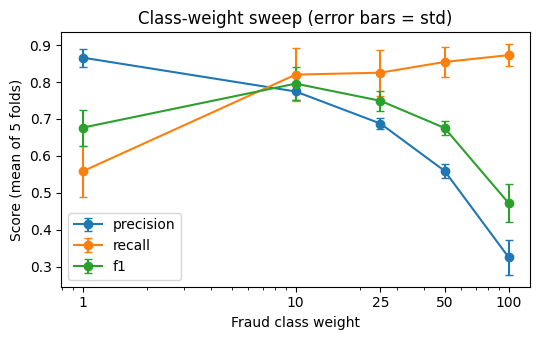

In [ ]:
# ===============================================================
# 8. CLASS-WEIGHT SWEEP (all 5 folds per weight)
# Takes ~10-15 minutes: 4 weights x 5 folds = 20 training runs
# ===============================================================
fraud_weights_to_try = [1, 10, 25, 50, 100]
cv_results = {1: baseline}   # weight 1 was already run above

for fw in fraud_weights_to_try[1:]:
    cv_results[fw] = run_cv(fraud_weight=fw)
    print(f"weight={fw:>4} done")

metric_cols = ["precision", "recall", "f1"]
sweep_df = pd.DataFrame([
    {"fraud_weight": fw, **cv_results[fw]["metrics"][metric_cols].mean().to_dict()}
    for fw in fraud_weights_to_try
])
sweep_std = pd.DataFrame([
    {"fraud_weight": fw, **cv_results[fw]["metrics"][metric_cols].std().to_dict()}
    for fw in fraud_weights_to_try
])
print("\nMean across 5 folds:"); print(sweep_df.round(4))
print("\nStd across 5 folds:");  print(sweep_std.round(4))

best_weight = int(sweep_df.loc[sweep_df["f1"].idxmax(), "fraud_weight"])
print(f"\nBest fraud weight (highest mean F1): {best_weight}")

# --- Figure: precision / recall / F1 vs weight, with std error bars ---
plt.figure(figsize=(5.5, 3.5))
for col in metric_cols:
    plt.errorbar(sweep_df["fraud_weight"], sweep_df[col], yerr=sweep_std[col],
                 marker="o", capsize=3, label=col)
plt.xscale("log")
plt.xticks(fraud_weights_to_try, fraud_weights_to_try)
plt.xlabel("Fraud class weight"); plt.ylabel("Score (mean of 5 folds)")
plt.title("Class-weight sweep (error bars = std)")
plt.legend(); plt.tight_layout(); plt.show()

## 9. Baseline vs best weight
Per-fold results for the chosen weight, a side-by-side summary with the baseline, and confusion matrices added up over all 5 validation folds. The confusion matrices show *which* errors change: weighting should turn missed frauds (false negatives) into caught frauds, at the cost of some extra false alarms (false positives).

Per-fold metrics, weight = 10:
   fold  accuracy  precision  recall      f1
0     1    0.9993     0.7722  0.8133  0.7922
1     2    0.9993     0.7711  0.8533  0.8101
2     3    0.9991     0.7465  0.6974  0.7211
3     4    0.9994     0.7701  0.8816  0.8221
4     5    0.9994     0.8125  0.8553  0.8333

Summary (5-fold CV, threshold 0.5):
           Baseline mean  Baseline std  Weight 10 mean  Weight 10 std
accuracy          0.9991        0.0001          0.9993         0.0001
precision         0.8663        0.0245          0.7745         0.0238
recall            0.5580        0.0689          0.8202         0.0729
f1                0.6764        0.0487          0.7958         0.0444


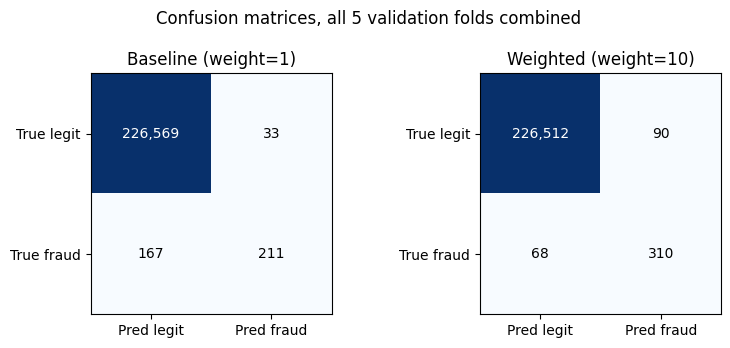

In [ ]:
# ===============================================================
# 9. BEST WEIGHT VS BASELINE
# ===============================================================
weighted = cv_results[best_weight]
print(f"Per-fold metrics, weight = {best_weight}:")
print(weighted["metrics"].round(4))

cols = ["accuracy", "precision", "recall", "f1"]
summary = pd.DataFrame({
    "Baseline mean": baseline["metrics"][cols].mean(),
    "Baseline std": baseline["metrics"][cols].std(),
    f"Weight {best_weight} mean": weighted["metrics"][cols].mean(),
    f"Weight {best_weight} std": weighted["metrics"][cols].std(),
})
print("\nSummary (5-fold CV, threshold 0.5):")
print(summary.round(4))

# --- Figure: confusion matrices summed over the 5 validation folds ---
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, res, title in zip(axes, [baseline, weighted],
                          ["Baseline (weight=1)", f"Weighted (weight={best_weight})"]):
    cm = sum(res["cms"])   # add up the 5 folds
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred legit", "Pred fraud"])
    ax.set_yticklabels(["True legit", "True fraud"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    ax.set_title(title)
plt.suptitle("Confusion matrices, all 5 validation folds combined")
plt.tight_layout(); plt.show()

## 10. Threshold tuning
The model is trained to minimise cross-entropy, but the actual decision is "flag or don't flag", made with a threshold $t$. The default $t = 0.5$ isn't chosen by the loss; it's just a convention. Here I try thresholds from 0.05 to 0.95 on the **validation** predictions (all 5 folds combined, never the test set) and pick the one with the best F1.

This is one place where the training loss and the real objective differ: cross-entropy rewards well-ranked probabilities, while the task is judged on the yes/no decisions.

    threshold  precision  recall      f1
0        0.05     0.1477  0.8810  0.2530
1        0.10     0.4509  0.8624  0.5922
2        0.15     0.6108  0.8386  0.7068
3        0.20     0.6555  0.8307  0.7328
4        0.25     0.6996  0.8254  0.7573
5        0.30     0.7464  0.8254  0.7839
6        0.35     0.7591  0.8254  0.7909
7        0.40     0.7641  0.8228  0.7924
8        0.45     0.7711  0.8201  0.7949
9        0.50     0.7750  0.8201  0.7969
10       0.55     0.7826  0.8095  0.7958
11       0.60     0.7818  0.7963  0.7890
12       0.65     0.7958  0.7937  0.7947
13       0.70     0.7995  0.7910  0.7952
14       0.75     0.8122  0.7778  0.7946
15       0.80     0.8571  0.7619  0.8067
16       0.85     0.8625  0.7302  0.7908
17       0.90     0.8624  0.6799  0.7604
18       0.95     0.8613  0.6243  0.7239

Best threshold on validation: 0.8


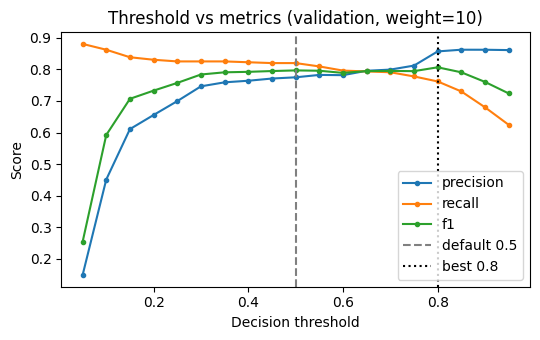

In [ ]:
# ===============================================================
# 10. THRESHOLD TUNING (validation predictions only)
# ===============================================================
all_proba = np.concatenate(weighted["probas"])
all_y = np.concatenate(weighted["labels"])

thr_rows = []
for t in np.arange(0.05, 0.96, 0.05):
    p = (all_proba >= t).astype(int)
    thr_rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(all_y, p, zero_division=0),
        "recall": recall_score(all_y, p, zero_division=0),
        "f1": f1_score(all_y, p, zero_division=0),
    })
thr_df = pd.DataFrame(thr_rows)
best_threshold = float(thr_df.loc[thr_df["f1"].idxmax(), "threshold"])
print(thr_df.round(4))
print(f"\nBest threshold on validation: {best_threshold}")

# --- Figure: metrics vs threshold ---
plt.figure(figsize=(5.5, 3.5))
for col in ["precision", "recall", "f1"]:
    plt.plot(thr_df["threshold"], thr_df[col], marker="o", markersize=3, label=col)
plt.axvline(0.5, ls="--", color="gray", label="default 0.5")
plt.axvline(best_threshold, ls=":", color="black", label=f"best {best_threshold}")
plt.xlabel("Decision threshold"); plt.ylabel("Score")
plt.title(f"Threshold vs metrics (validation, weight={best_weight})")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Final model and test-set evaluation
The final model is trained once on the full 80% training set using the chosen weight, then evaluated on the 20% test set. This is the first and only time the test set is used, so these numbers are an unbiased estimate of performance on new data.

The **train vs CV vs test** table checks for overfitting: if training scores were much higher than CV/test, the model would be memorising the training data. The loss curve shows how training converged.

Iter     0 | loss = 0.693147
Iter   200 | loss = 0.066089
Iter   400 | loss = 0.039996
Iter   600 | loss = 0.031542
Iter   800 | loss = 0.027414
Iter  1000 | loss = 0.024982
Iter  1200 | loss = 0.023383
Iter  1400 | loss = 0.022252
Iter  1600 | loss = 0.021410
Iter  1800 | loss = 0.020758
Iter  1999 | loss = 0.020239

Train vs CV vs Test:
           Train (t=0.5)  CV mean (t=0.5)  Test (t=0.5)  Test (t=0.8)
precision         0.7839           0.7745        0.8276        0.8750
recall            0.8254           0.8202        0.7579        0.7368
f1                0.8041           0.7958        0.7912        0.8000

Test PR-AUC (threshold-independent): 0.6906

Test confusion matrix, t=0.5  [[TN FP] [FN TP]]:
[[56636    15]
 [   23    72]]

Test confusion matrix, t=0.8:
[[56641    10]
 [   25    70]]


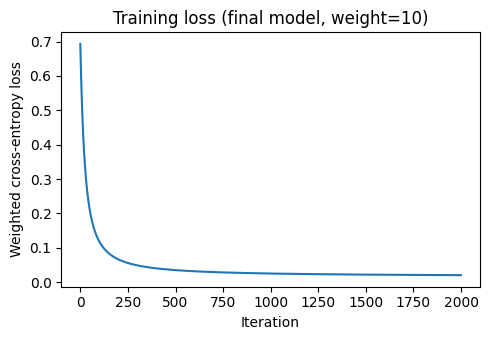

In [ ]:
# ===============================================================
# 11. FINAL MODEL, TEST RESULTS, OVERFITTING CHECK, LOSS CURVE
# ===============================================================
final_model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000, verbose_every=200)
final_model.fit(X_train_final_scaled, y_train.values, class_weight={0: 1, 1: best_weight})

test_proba = final_model.predict_proba(X_test_final_scaled)
test_preds = (test_proba >= 0.5).astype(int)                    # default threshold
test_preds_tuned = (test_proba >= best_threshold).astype(int)   # threshold from validation
train_preds = final_model.predict(X_train_final_scaled)
test_pr_auc = average_precision_score(y_test, test_proba)

def scores(y_true, preds):
    return {"precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0)}

comparison = pd.DataFrame({
    "Train (t=0.5)": scores(y_train, train_preds),
    "CV mean (t=0.5)": weighted["metrics"][["precision", "recall", "f1"]].mean().to_dict(),
    "Test (t=0.5)": scores(y_test, test_preds),
    f"Test (t={best_threshold})": scores(y_test, test_preds_tuned),
})
print("\nTrain vs CV vs Test:")
print(comparison.round(4))
print(f"\nTest PR-AUC (threshold-independent): {test_pr_auc:.4f}")
print("\nTest confusion matrix, t=0.5  [[TN FP] [FN TP]]:")
print(confusion_matrix(y_test, test_preds))
print(f"\nTest confusion matrix, t={best_threshold}:")
print(confusion_matrix(y_test, test_preds_tuned))

# --- Figure: training loss curve ---
plt.figure(figsize=(5, 3.5))
plt.plot(final_model.loss_history)
plt.xlabel("Iteration"); plt.ylabel("Weighted cross-entropy loss")
plt.title(f"Training loss (final model, weight={best_weight})")
plt.tight_layout(); plt.show()

## 12. Test-set error analysis
- **Precision-recall curve:** shows every precision/recall trade-off the model can offer as the threshold moves. PR-AUC summarises it in one number; the dashed line is a random guesser (equal to the fraud rate).
- **Predicted-probability histogram:** fraud vs legit. Fraud cases sitting at low probabilities are the ones the model misses at any reasonable threshold. This is where a linear model runs out of ability.
- **Learned weights:** the features the model relies on most. These can be compared with the correlation check in Section 3.

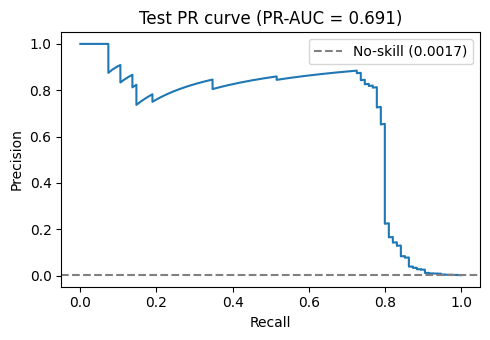

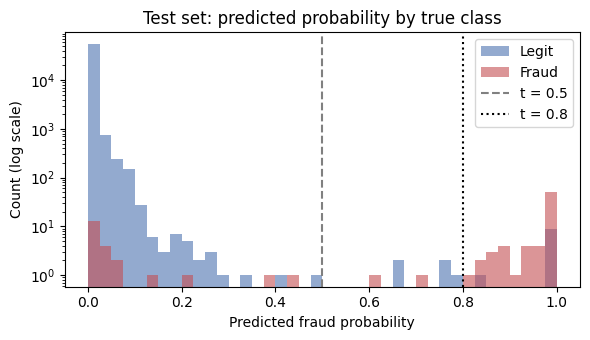

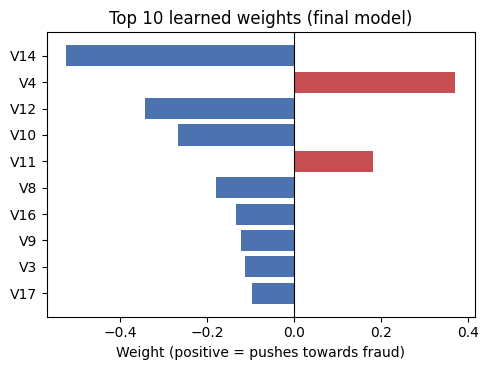

In [ ]:
# ===============================================================
# 12. PR CURVE, PROBABILITY HISTOGRAM, LEARNED WEIGHTS
# ===============================================================

# --- Precision-recall curve ---
prec, rec, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(5, 3.5))
plt.plot(rec, prec)
plt.axhline(y_test.mean(), ls="--", color="gray", label=f"No-skill ({y_test.mean():.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Test PR curve (PR-AUC = {test_pr_auc:.3f})")
plt.legend(); plt.tight_layout(); plt.show()

# --- Predicted probability by true class ---
bins = np.linspace(0, 1, 41)
plt.figure(figsize=(6, 3.5))
plt.hist(test_proba[y_test.values == 0], bins=bins, alpha=0.6, label="Legit", color="#4c72b0")
plt.hist(test_proba[y_test.values == 1], bins=bins, alpha=0.6, label="Fraud", color="#c44e52")
plt.yscale("log")
plt.axvline(0.5, ls="--", color="gray", label="t = 0.5")
plt.axvline(best_threshold, ls=":", color="black", label=f"t = {best_threshold}")
plt.xlabel("Predicted fraud probability"); plt.ylabel("Count (log scale)")
plt.title("Test set: predicted probability by true class")
plt.legend(); plt.tight_layout(); plt.show()

# --- Top 10 learned weights by size ---
coef = pd.Series(final_model.weights, index=X.columns)
top = coef.reindex(coef.abs().sort_values(ascending=False).index[:10])[::-1]
plt.figure(figsize=(5, 3.8))
plt.barh(top.index, top.values, color=["#c44e52" if v > 0 else "#4c72b0" for v in top.values])
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Weight (positive = pushes towards fraud)")
plt.title("Top 10 learned weights (final model)")
plt.tight_layout(); plt.show()